In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch

In [2]:
model_file = 'checkpoint_copies/lodopab_cp_64px1e4_mp.pt'

In [3]:
epoch = None
prediction_images = None
train_loss_values = None
eval_loss_values = None
eval_ssim_values = None

if os.path.exists(model_file):
    checkpoint = torch.load(model_file, map_location='cpu', weights_only=True)
    epoch = checkpoint['epoch']
    gt_images = checkpoint['gt_images']
    baseline_images = checkpoint['baseline_images']
    prediction_images = checkpoint['prediction_images']
    train_loss_values = checkpoint['train_loss_values']
    baseline_loss_values = checkpoint['baseline_loss_values']
    baseline_ssim_values = checkpoint['baseline_ssim_values']
    eval_loss_values = checkpoint['eval_loss_values']
    eval_ssim_values = checkpoint['eval_ssim_values']
    print(f'Number of Prediction Images: {len(prediction_images)}')
    print(f'Prediction Images Shape: {prediction_images[0].shape}')
else:
    print(f'Did not find model file.')

Number of Prediction Images: 179
Prediction Images Shape: torch.Size([1, 64, 64])


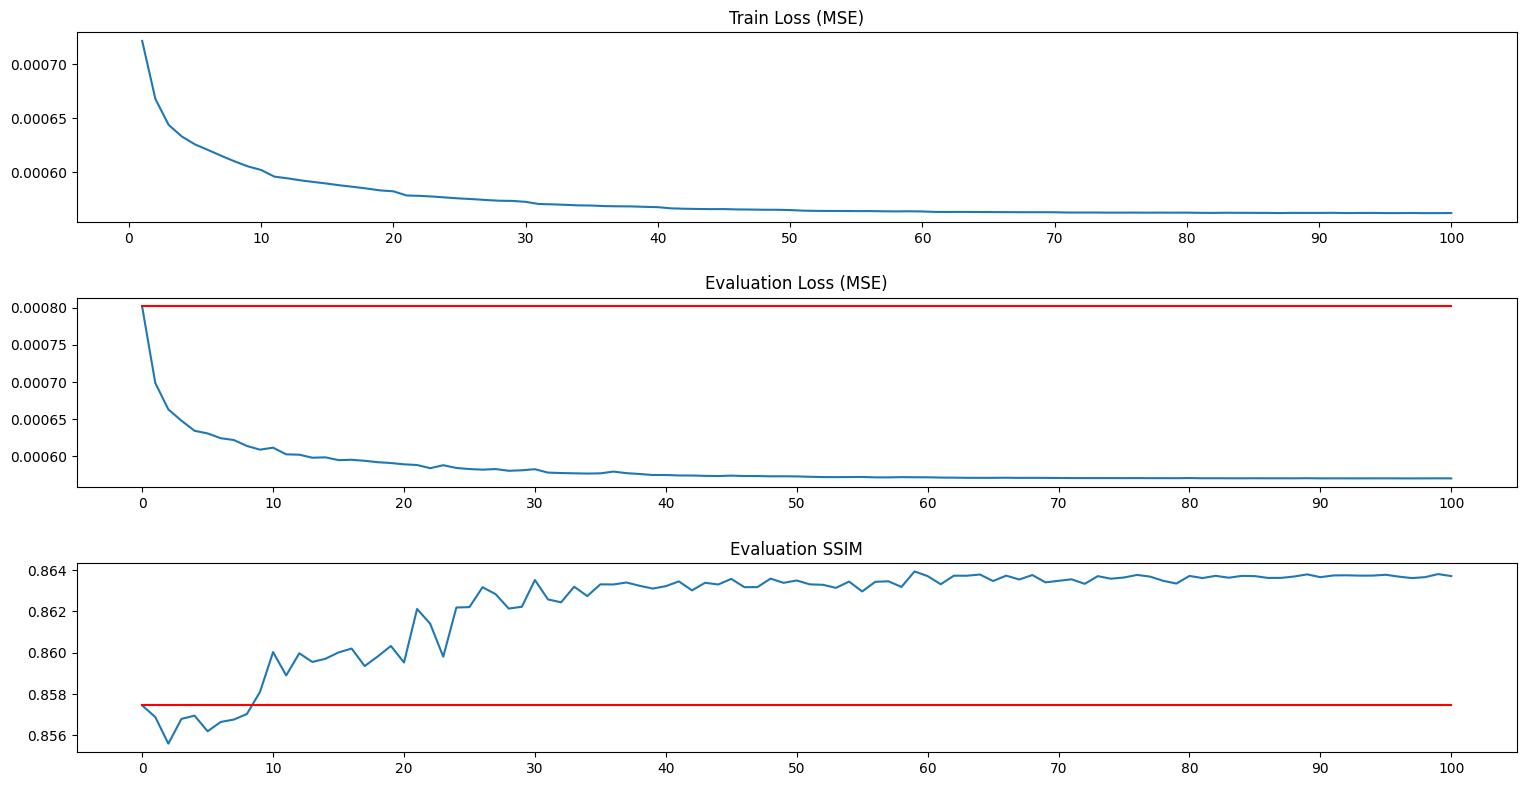

In [4]:
epochs = np.arange(0, len(train_loss_values))
train_loss_values = np.array(train_loss_values)
baseline_loss_values = np.array(baseline_loss_values)
baseline_ssim_values = np.array(baseline_ssim_values)
eval_loss_values = np.array(eval_loss_values)
eval_ssim_values = np.array(eval_ssim_values)

plt.figure(figsize=(18, 9))
plt.subplot(3, 1, 1)
plt.title('Train Loss (MSE)')
plt.plot(epochs, train_loss_values)
plt.xticks(epochs[::10])
plt.subplot(3, 1, 2)
plt.title('Evaluation Loss (MSE)')
plt.plot(epochs, eval_loss_values)
plt.plot(epochs, baseline_loss_values, 'r')
plt.xticks(epochs[::10])
plt.subplot(3, 1, 3)
plt.title('Evaluation SSIM')
plt.plot(epochs, eval_ssim_values)
plt.plot(epochs, baseline_ssim_values, 'r')
plt.xticks(epochs[::10])
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)
plt.show()

In [5]:
print(f'Baseline Loss = {baseline_loss_values[0]:.8f} / Baseline SSIM = {baseline_ssim_values[0]:8f}')

Baseline Loss = 0.00080206 / Baseline SSIM = 0.857461


In [6]:
for epoch, loss, ssim in zip(epochs, eval_loss_values, eval_ssim_values):
    print(f'Epoch {epoch:3d}: Evaluation Loss = {loss:.8f} / SSIM = {ssim:8f}')

Epoch   0: Evaluation Loss = 0.00080130 / SSIM = 0.857452
Epoch   1: Evaluation Loss = 0.00069887 / SSIM = 0.856889
Epoch   2: Evaluation Loss = 0.00066321 / SSIM = 0.855601
Epoch   3: Evaluation Loss = 0.00064805 / SSIM = 0.856799
Epoch   4: Evaluation Loss = 0.00063450 / SSIM = 0.856957
Epoch   5: Evaluation Loss = 0.00063094 / SSIM = 0.856200
Epoch   6: Evaluation Loss = 0.00062451 / SSIM = 0.856651
Epoch   7: Evaluation Loss = 0.00062208 / SSIM = 0.856767
Epoch   8: Evaluation Loss = 0.00061410 / SSIM = 0.857037
Epoch   9: Evaluation Loss = 0.00060911 / SSIM = 0.858103
Epoch  10: Evaluation Loss = 0.00061181 / SSIM = 0.860032
Epoch  11: Evaluation Loss = 0.00060283 / SSIM = 0.858900
Epoch  12: Evaluation Loss = 0.00060235 / SSIM = 0.859973
Epoch  13: Evaluation Loss = 0.00059829 / SSIM = 0.859554
Epoch  14: Evaluation Loss = 0.00059876 / SSIM = 0.859709
Epoch  15: Evaluation Loss = 0.00059504 / SSIM = 0.860014
Epoch  16: Evaluation Loss = 0.00059549 / SSIM = 0.860202
Epoch  17: Eva

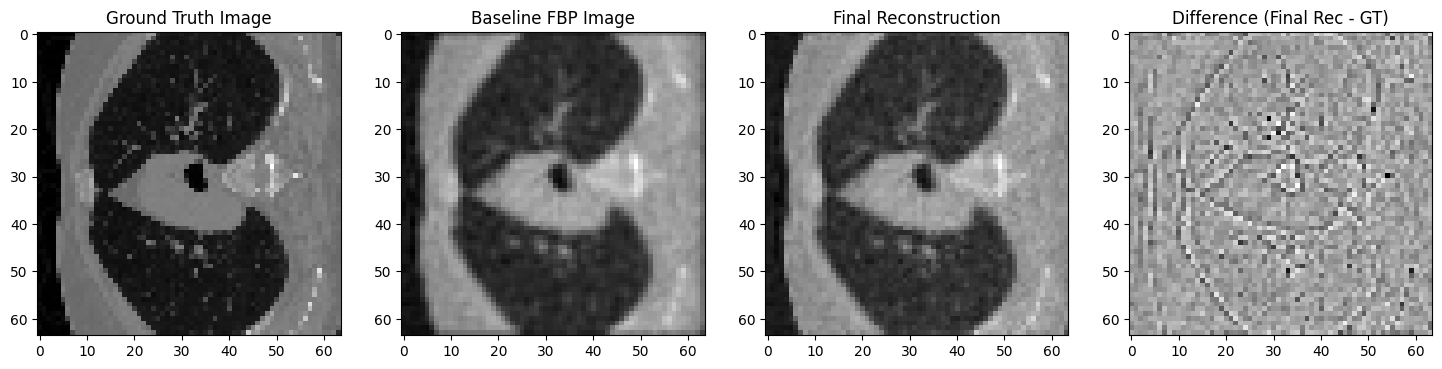

In [7]:
plt.figure(figsize=(18, 9))
plt.subplot(1, 4, 1)
plt.title('Ground Truth Image')
plt.imshow(gt_images[0].squeeze().numpy(), cmap='gray')
plt.subplot(1, 4, 2)
plt.title(f'Baseline FBP Image')
plt.imshow(baseline_images[0].squeeze().numpy(), cmap='gray')
plt.subplot(1, 4, 3)
plt.title(f'Final Reconstruction')
plt.imshow(prediction_images[0].squeeze().numpy(), cmap='gray')
plt.subplot(1, 4, 4)
plt.title('Difference (Final Rec - GT)')
plt.imshow((prediction_images[0] - gt_images[0]).squeeze().numpy(), cmap='gray')
plt.show()